In [1]:
import matplotlib.pyplot as plt
from qiskit.circuit import ParameterVector
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate
from scipy.ndimage import label

In [2]:
def testf(ab: dict):
    ab["abd"] = 123


a = {"a": 1, "b": 2, "c": 3}
testf(a)
a

{'a': 1, 'b': 2, 'c': 3, 'abd': 123}

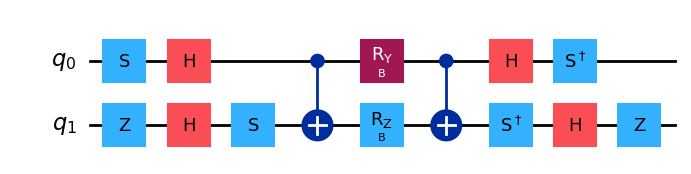

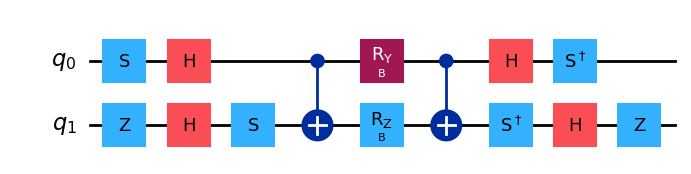

In [3]:


qc = QuantumCircuit(2, name="$R_{XY+YX}$")
b = Parameter('B')
qc.z(1)
qc.s(0)
qc.h(1)
qc.h(0)
qc.s(1)
qc.cx(0, 1)
qc.ry(b, 0)
qc.rz(b, 1)
qc.cx(0, 1)
qc.h(0)
qc.sdg(1)
qc.sdg(0)
qc.h(1)
qc.z(1)
base_gate = qc.to_gate(label="$R_{XY+YX}$")
qc.draw("mpl")

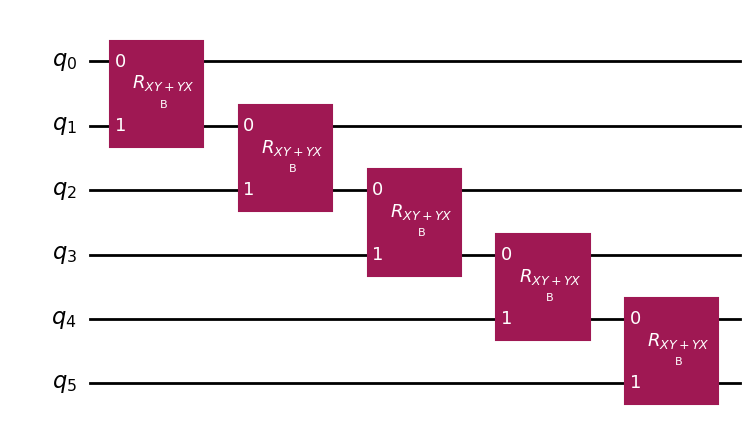

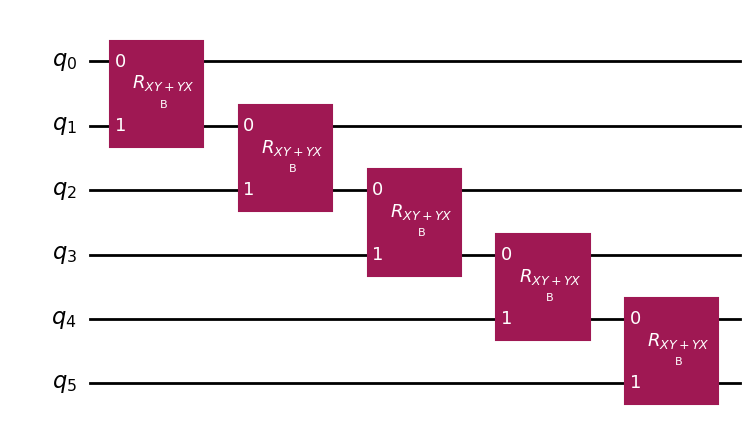

In [4]:
mqc = QuantumCircuit(6)
my_params = ParameterVector("A", 5)
# base_gate = RYGate(Parameter("C"))
for i in range(5):
    temp_qc = QuantumCircuit(2)
    temp_qc.append(base_gate.copy(), [0, 1])
    temp_qc.assign_parameters([my_params[i]])
    gate = temp_qc.to_gate(label=base_gate.name)
    # gate = base_gate.copy()
    # gate.params[0] = my_params[i]
    # gate = qc.to_gate(label="$R_{XY+YX}$", parameter_map={qc.parameters[0]: my_params[i]})
    mqc.append(gate, [i, i + 1])
mqc.draw("mpl")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
0


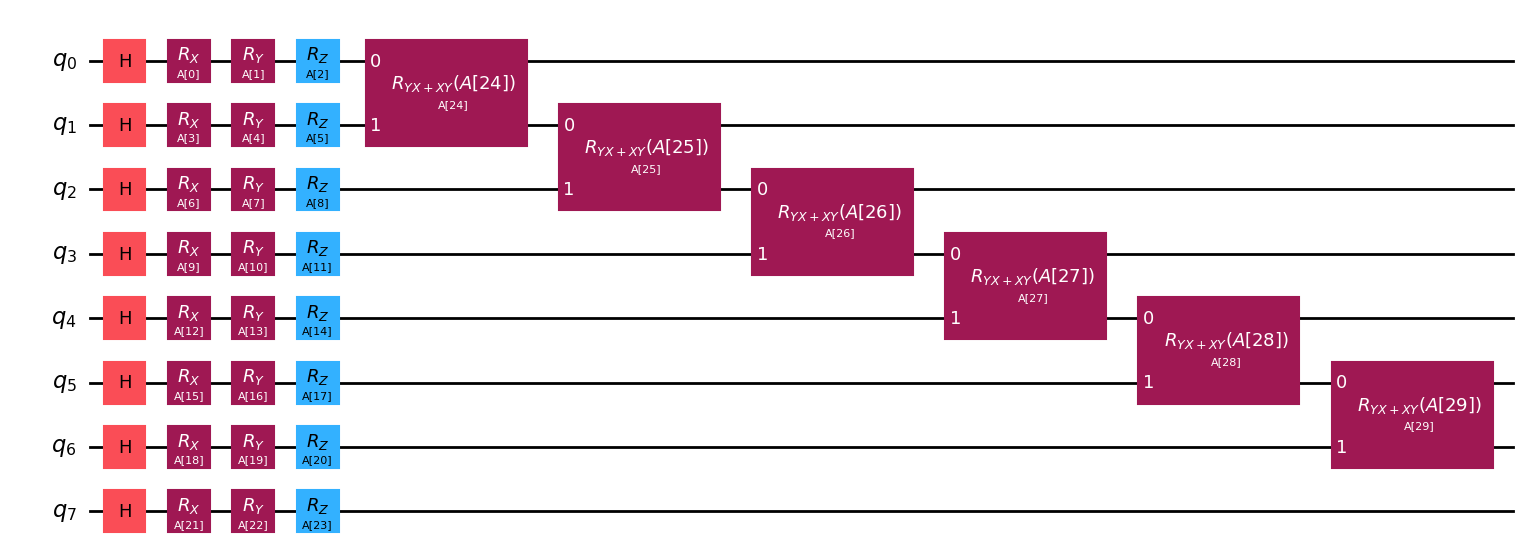

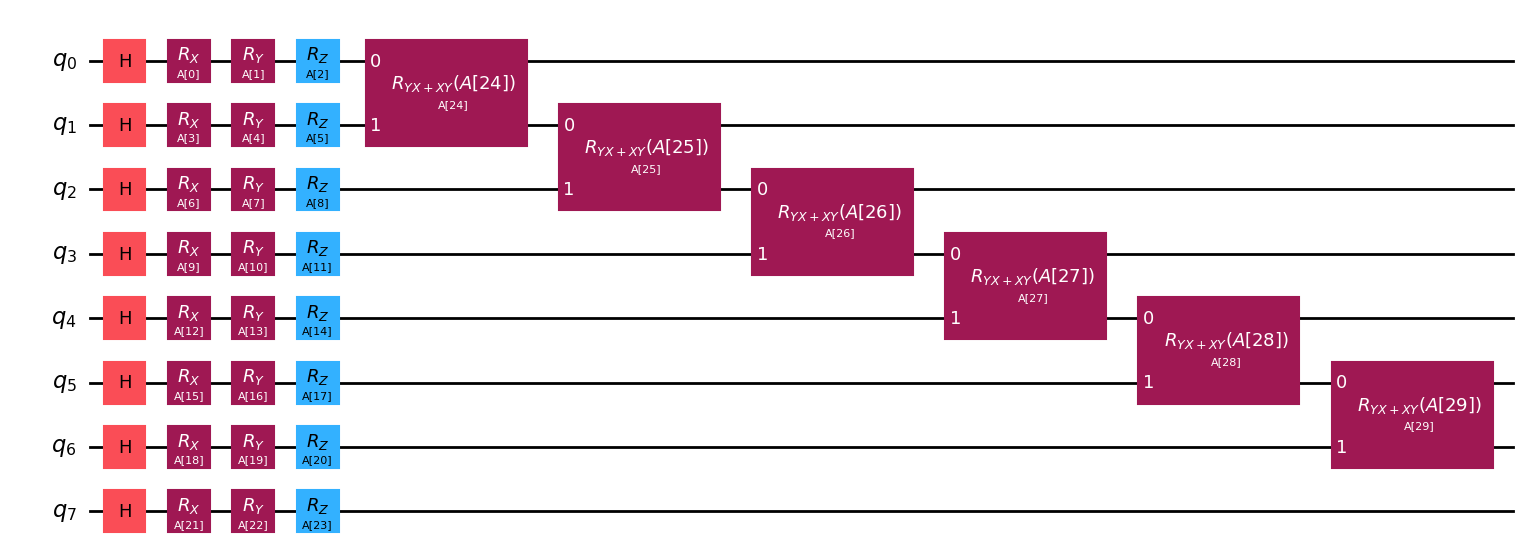

In [5]:
from solver.circuits import YXPlusXYRYAdaptAnsatz1, HardwareAdaptAnsatz1
import random

li = random.sample(range(0, 15), 15)
li = list(range(0, 30))
# li.insert(4, 25)
print(li)
temp = HardwareAdaptAnsatz1(8)
print(temp.set_ansatz(li))
circ = temp()
circ.draw("mpl")

In [6]:
circ.parameters

ParameterView([ParameterVectorElement(A[0]), ParameterVectorElement(A[1]), ParameterVectorElement(A[2]), ParameterVectorElement(A[3]), ParameterVectorElement(A[4]), ParameterVectorElement(A[5]), ParameterVectorElement(A[6]), ParameterVectorElement(A[7]), ParameterVectorElement(A[8]), ParameterVectorElement(A[9]), ParameterVectorElement(A[10]), ParameterVectorElement(A[11]), ParameterVectorElement(A[12]), ParameterVectorElement(A[13]), ParameterVectorElement(A[14]), ParameterVectorElement(A[15]), ParameterVectorElement(A[16]), ParameterVectorElement(A[17]), ParameterVectorElement(A[18]), ParameterVectorElement(A[19]), ParameterVectorElement(A[20]), ParameterVectorElement(A[21]), ParameterVectorElement(A[22]), ParameterVectorElement(A[23]), ParameterVectorElement(A[24]), ParameterVectorElement(A[25]), ParameterVectorElement(A[26]), ParameterVectorElement(A[27]), ParameterVectorElement(A[28]), ParameterVectorElement(A[29])])

In [7]:
circ.draw("text")

┌───┐┌─────────────┐ ┌─────────────┐ ┌─────────────┐ »
q_0: ┤ H ├┤ $R_X$(A[0]) ├─┤ $R_Y$(A[1]) ├─┤ $R_Z$(A[2]) ├─»
     ├───┤├─────────────┤ ├─────────────┤ ├─────────────┤ »
q_1: ┤ H ├┤ $R_X$(A[3]) ├─┤ $R_Y$(A[4]) ├─┤ $R_Z$(A[5]) ├─»
     ├───┤├─────────────┤ ├─────────────┤ ├─────────────┤ »
q_2: ┤ H ├┤ $R_X$(A[6]) ├─┤ $R_Y$(A[7]) ├─┤ $R_Z$(A[8]) ├─»
     ├───┤├─────────────┤ ├─────────────┴┐├─────────────┴┐»
q_3: ┤ H ├┤ $R_X$(A[9]) ├─┤ $R_Y$(A[10]) ├┤ $R_Z$(A[11]) ├»
     ├───┤├─────────────┴┐├──────────────┤├──────────────┤»
q_4: ┤ H ├┤ $R_X$(A[12]) ├┤ $R_Y$(A[13]) ├┤ $R_Z$(A[14]) ├»
     ├───┤├──────────────┤├──────────────┤├──────────────┤»
q_5: ┤ H ├┤ $R_X$(A[15]) ├┤ $R_Y$(A[16]) ├┤ $R_Z$(A[17]) ├»
     ├───┤├──────────────┤├──────────────┤├──────────────┤»
q_6: ┤ H ├┤ $R_X$(A[18]) ├┤ $R_Y$(A[19]) ├┤ $R_Z$(A[20]) ├»
     ├───┤├──────────────┤├──────────────┤├──────────────┤»
q_7: ┤ H ├┤ $R_X$(A[21]) ├┤ $R_Y$(A[22]) ├┤ $R_Z$(A[23]) ├»
     └───┘└──────────────┘└──────────────┘└──────────────┘»
«     ┌───────────────────────────────────────┐»
«q_0: ┤0                                      ├»
«     │  $R_{YX+XY}\left(A[24]\right)$(A[24]) │»
«q_1: ┤1                                      ├»
«     └───────────────────────────────────────┘»
«q_2: ─────────────────────────────────────────»
«                                              »
«q_3: ─────────────────────────────────────────»
«                                              »
«q_4: ─────────────────────────────────────────»
«                                              »
«q_5: ─────────────────────────────────────────»
«                                              »
«q_6: ─────────────────────────────────────────»
«                                              »
«q_7: ─────────────────────────────────────────»
«                                              »
«                                              »
«q_0: ─────────────────────────────────────────»
«     ┌───────────────────────────────────────┐»
«q_1: ┤0                                      ├»
«     │  $R_{YX+XY}\left(A[25]\right)$(A[25]) │»
«q_2: ┤1                                      ├»
«     └───────────────────────────────────────┘»
«q_3: ─────────────────────────────────────────»
«                                              »
«q_4: ─────────────────────────────────────────»
«                                              »
«q_5: ─────────────────────────────────────────»
«                                              »
«q_6: ─────────────────────────────────────────»
«                                              »
«q_7: ─────────────────────────────────────────»
«                                              »
«                                              »
«q_0: ─────────────────────────────────────────»
«                                              »
«q_1: ─────────────────────────────────────────»
«     ┌───────────────────────────────────────┐»
«q_2: ┤0                                      ├»
«     │  $R_{YX+XY}\left(A[26]\right)$(A[26]) │»
«q_3: ┤1                                      ├»
«     └───────────────────────────────────────┘»
«q_4: ─────────────────────────────────────────»
«                                              »
«q_5: ─────────────────────────────────────────»
«                                              »
«q_6: ─────────────────────────────────────────»
«                                              »
«q_7: ─────────────────────────────────────────»
«                                              »
«                                              »
«q_0: ─────────────────────────────────────────»
«                                              »
«q_1: ─────────────────────────────────────────»
«                                              »
«q_2: ─────────────────────────────────────────»
«     ┌───────────────────────────────────────┐»
«q_3: ┤0                                      ├»
«     │  $R_{YX+XY}\left(A[27]\right)$(A[27]) │»
«q_4: ┤1                                     

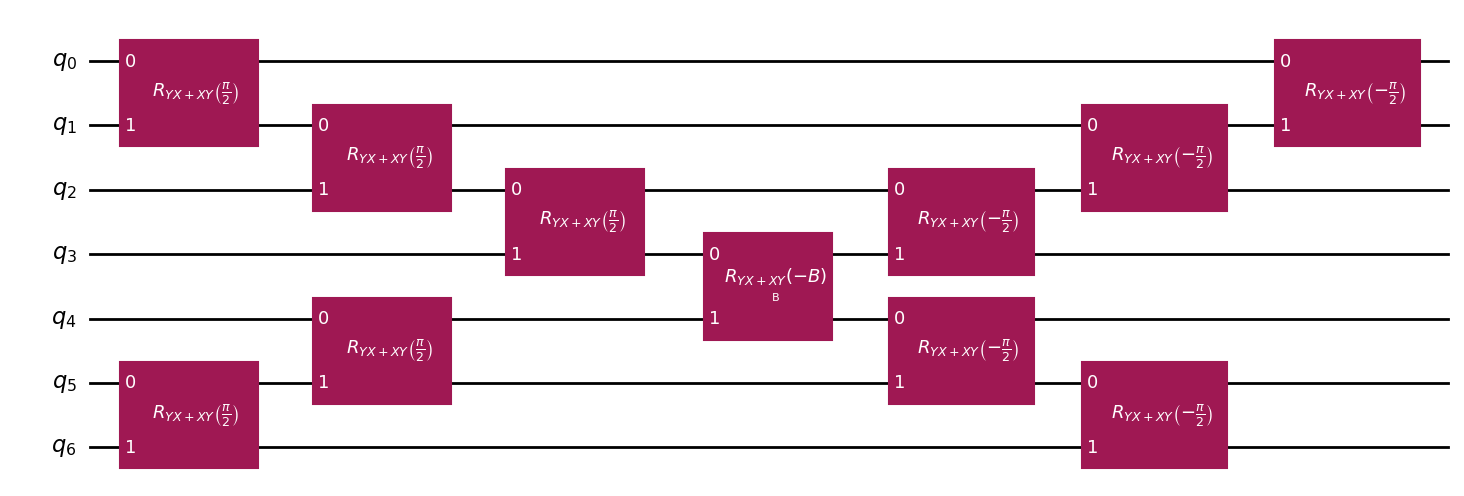

In [8]:
import sys

sys.path.insert(1, '..')
import importlib
from solver import circuits
from hamiltonian.free_wilson import FreeWilson2D

qc = circuits.build_r_xzy_m_yzx(Parameter('B'), 5, False)
qc.draw("mpl")
pass

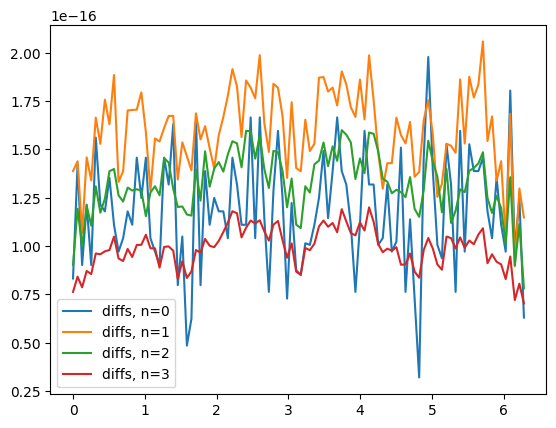

In [9]:
import numpy as np
from scipy.linalg import expm
from qiskit.quantum_info import Operator, SparsePauliOp
import matplotlib.pyplot as plt

x = np.array([[0, 1], [1, 0]])
y = np.array([[0, -1j], [1j, 0]])
z = np.array([[1, 0], [0, -1]])


def get_dense_matrix(n=0):
    result1 = x
    result2 = y
    for i in range(n):
        result1 = np.kron(result1, z)
        result2 = np.kron(result2, z)
    result1 = np.kron(result1, y)
    result2 = np.kron(result2, x)
    return -(
            result1 - result2) / 2.  # the extra - is here to compensate for qiskits qubit ordering when taking the tensor product


for n in range(4):
    xy = get_dense_matrix(n)
    theta_vals = np.linspace(0, 2 * np.pi, 100)
    matrices1 = [expm(1j * t * xy) for t in theta_vals]
    matrices2 = [Operator(circuits.build_r_xzy_m_yzx(t, n, False)).to_matrix() for t in theta_vals]
    diffs = [np.abs(m1 - m2).mean() for m1, m2 in zip(matrices1, matrices2)]
    plt.plot(theta_vals, diffs, label=f"diffs, n={n}")
# plt.plot(theta_vals, [np.real(m1[2,1]) for m1 in matrices1], label="m1")
# plt.plot(theta_vals, [np.real(m2[2,1]) for m2 in matrices2], label="m2")
plt.legend()
plt.show()

In [10]:
qc = QuantumCircuit(2)
qc.z(0)
qc.x(1)
Operator(qc).to_matrix()

array([[ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j]])

In [11]:
test = lambda a: circuits.combine_gates([circuits.build_r_xzy_m_yzx(-a, 0), circuits.build_r_xzy_m_yzx(-a, 2)],
                                        [[1, 2], [0, 1, 2, 3]],
                                        4,
                                        "$A_1(0,0)$")

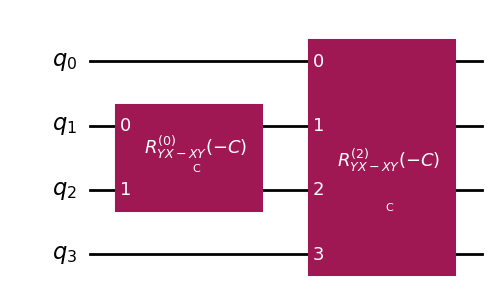

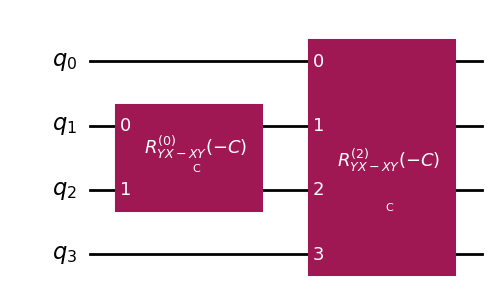

In [12]:
qc = QuantumCircuit(4)
qc.append(test(Parameter("C")), [0, 1, 2, 3])
# qc = qc.decompose()
qc = qc.decompose()
qc.draw("mpl")

[0, 1, 2, 3, 4, 5, 6, 7]
0


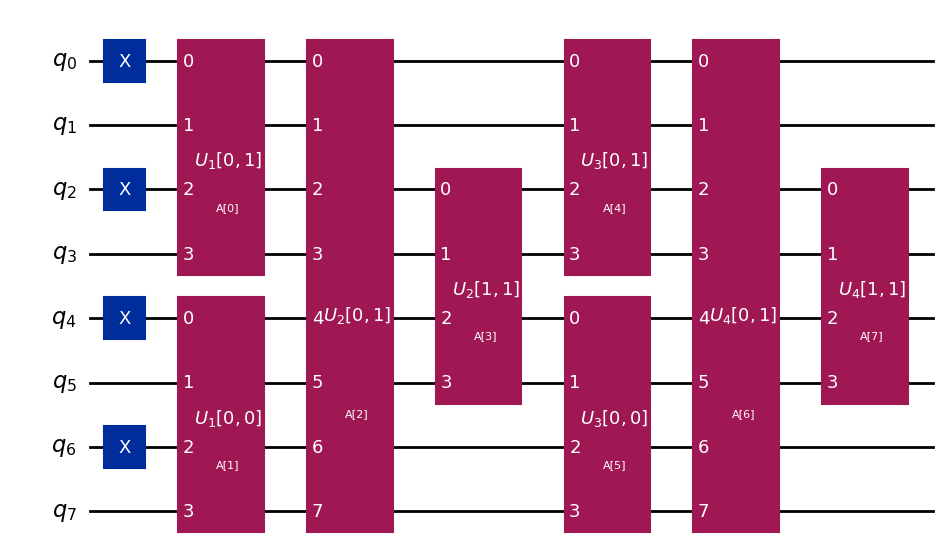

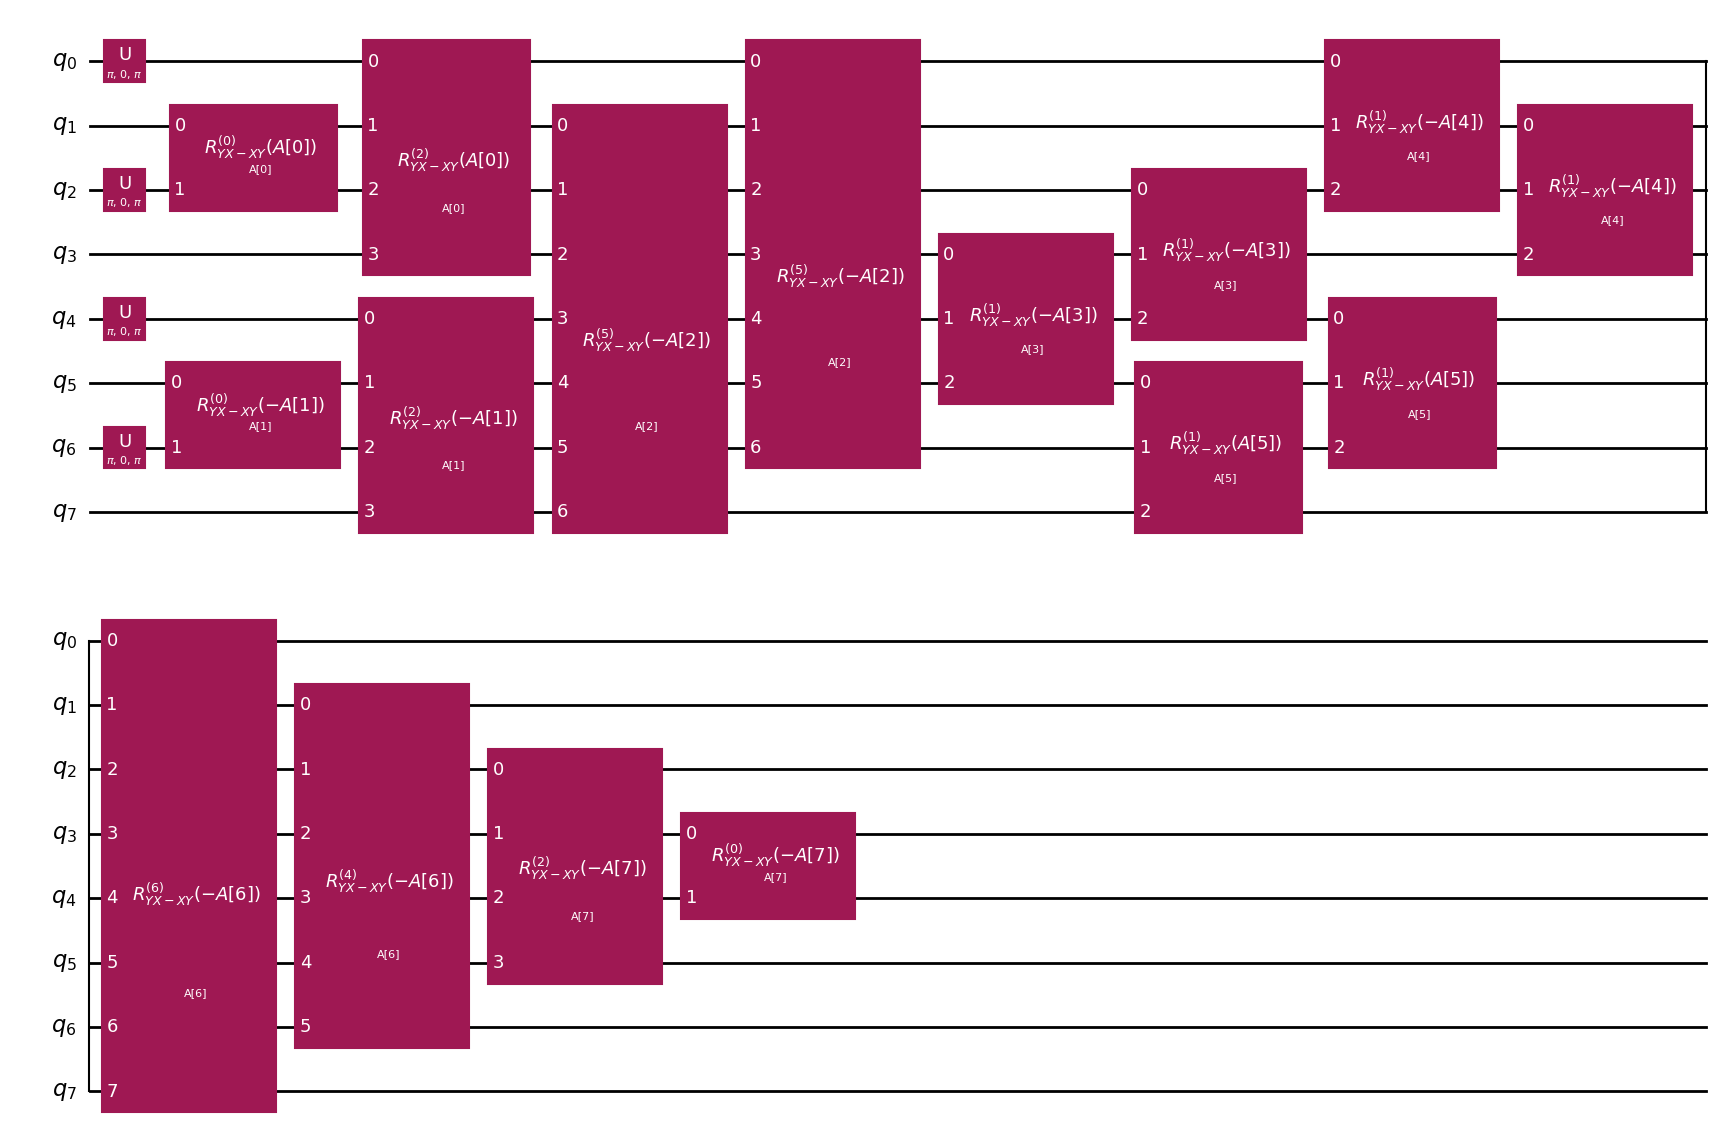

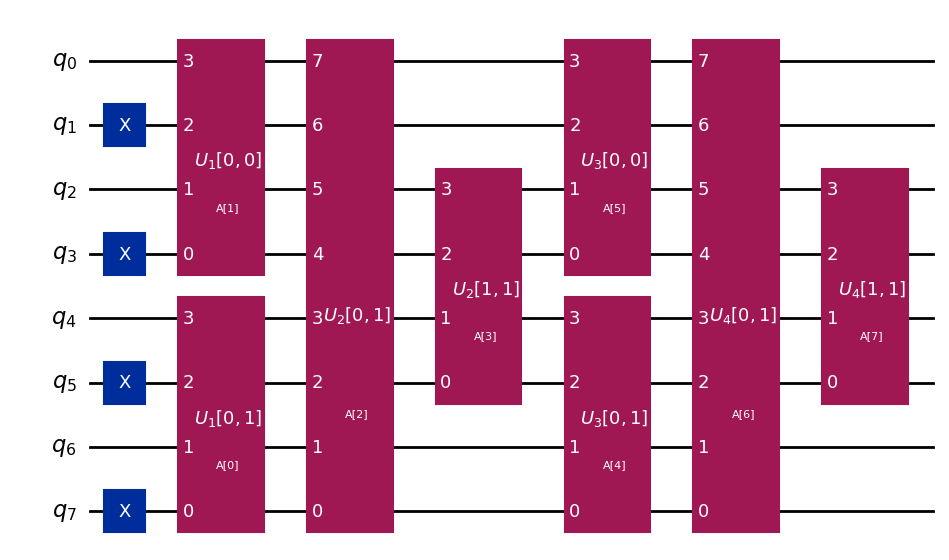

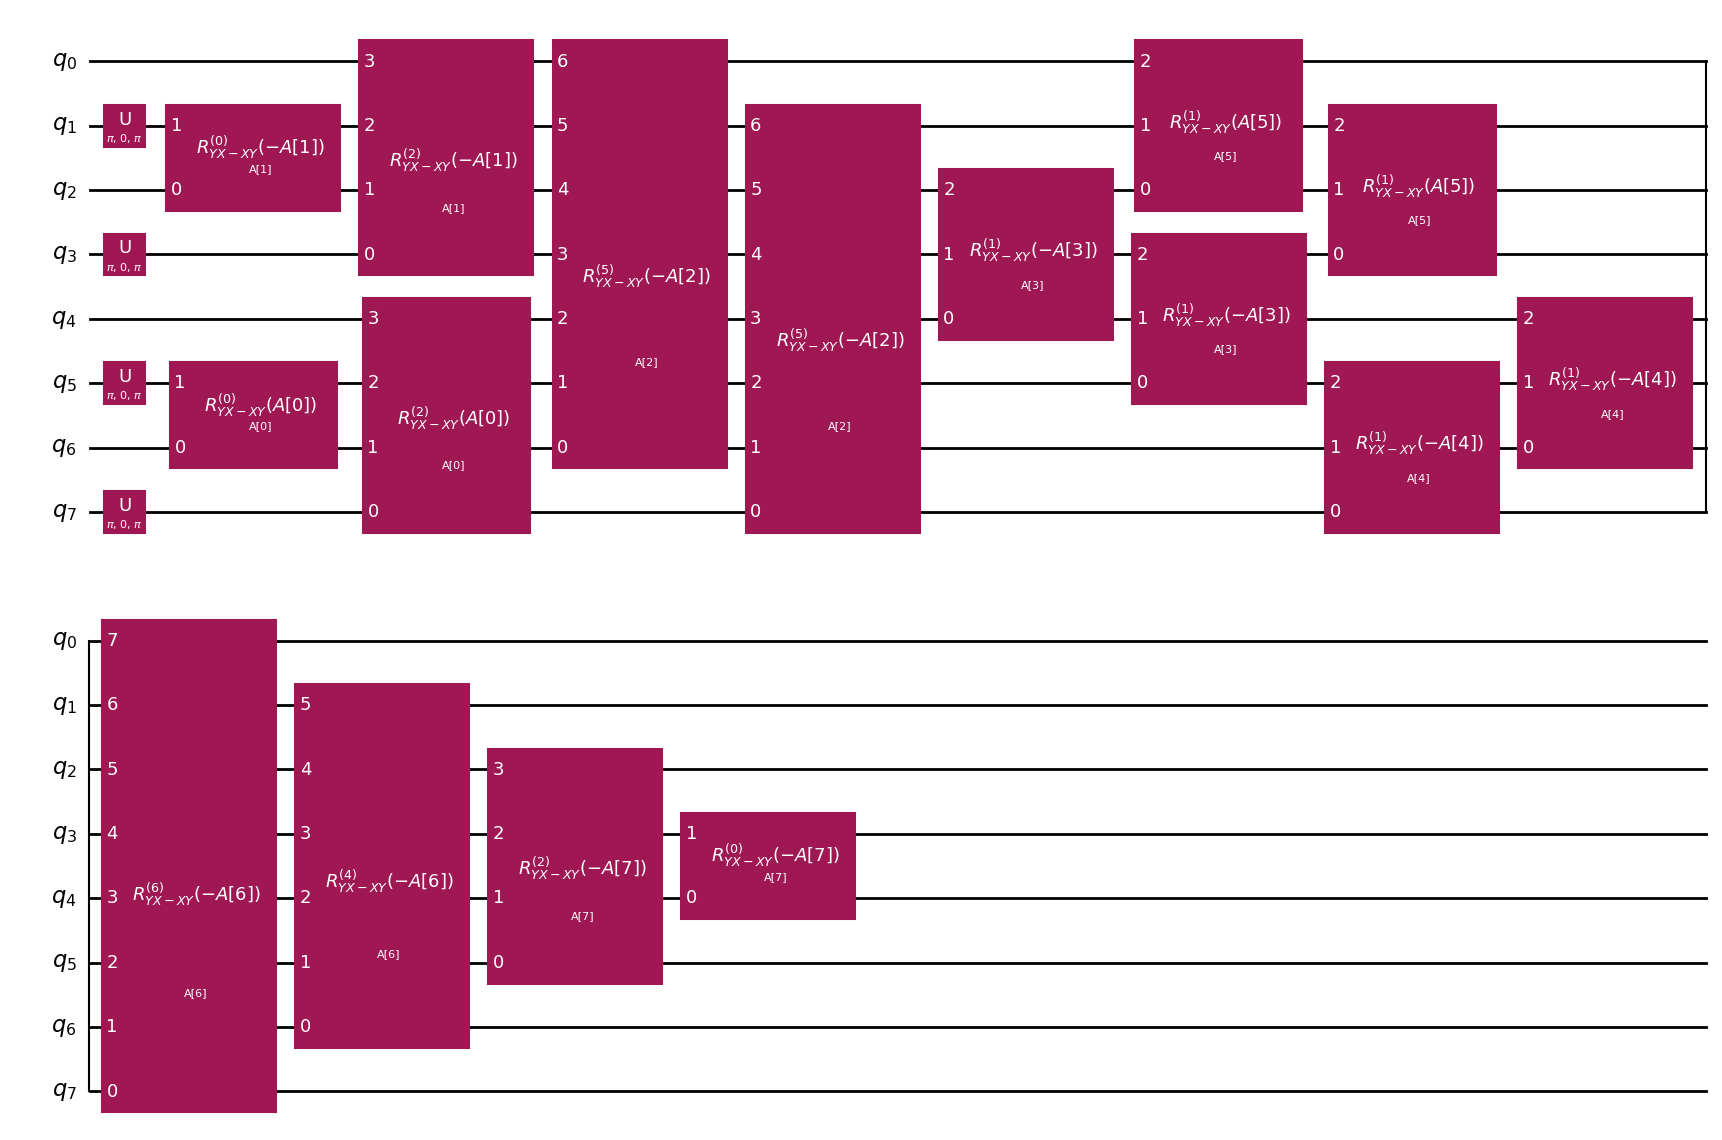

In [13]:
from solver.circuits import PhysicsAdaptAnsatz1

li = list(range(0, 8))
# li.insert(4, 25)
print(li)
temp = PhysicsAdaptAnsatz1(8)
print(temp.set_ansatz(li))
circ = temp()
circ.draw("mpl")
dec_circ = circ.decompose()
# dec_circ = dec_circ.decompose()
dec_circ.draw("mpl")
circ.reverse_bits().draw("mpl")
dec_circ.reverse_bits().draw("mpl")
pass

In [14]:
op = SparsePauliOp.from_sparse_list([("XY", [1, 2], 0.5j),
                                     ("YX", [1, 2], -0.5j),
                                     ("XZZY", list(range(0, 4)), 0.5j),
                                     ("YZZX", list(range(0, 4)), -0.5j),
                                     ], num_qubits=8)
print(op)
hamiltonian = FreeWilson2D(2, 2, 1, 1)
phi = hamiltonian.jwt_field
temp = -1j * (phi(1, 1, True) @ phi(2, 1, False) + phi(0, 1, True) @ phi(3, 1, False))
a_1_test_0_1 = 1j * (temp + temp.adjoint()).simplify()
print(a_1_test_0_1)
li = a_1_test_0_1.group_commuting()
print(li, len(li))
# tested this operator against the same one directly build from the phi fields
print((op-a_1_test_0_1).simplify())

SparsePauliOp(['IIIIIYXI', 'IIIIIXYI', 'IIIIYZZX', 'IIIIXZZY'],
              coeffs=[0.+0.5j, 0.-0.5j, 0.+0.5j, 0.-0.5j])
SparsePauliOp(['IIIIIYXI', 'IIIIIXYI', 'IIIIYZZX', 'IIIIXZZY'],
              coeffs=[ 0.+0.5j, -0.-0.5j,  0.+0.5j, -0.-0.5j])
[SparsePauliOp(['IIIIIYXI', 'IIIIIXYI', 'IIIIYZZX', 'IIIIXZZY'],
              coeffs=[0.+0.5j, 0.-0.5j, 0.+0.5j, 0.-0.5j])] 1
SparsePauliOp(['IIIIIIII'],
              coeffs=[0.+0.j])


In [15]:
op = SparsePauliOp.from_sparse_list([("ZX", [0, 1], 1),
                                     ], num_qubits=2)
op.to_matrix()

array([[ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j]])

In [16]:
c_op = SparsePauliOp.from_sparse_list([("XX", [1, 0], 0.5),  # need to flip order due to phi convention chosen
                                       ("YY", [1, 0], -0.5),
                                       ("IZ", [1, 0], -0.5),
                                       ("ZI", [1, 0], 0.5),
                                       ], num_qubits=2)
c_op.to_matrix()

array([[ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])

In [17]:
complete_c_op = c_op
for _ in range(3):
    complete_c_op = complete_c_op.tensor(c_op)
print(complete_c_op.to_matrix().shape)

(256, 256)


In [18]:
op = SparsePauliOp.from_sparse_list([
    ("XY", [1, 2], 0.5j),
    ("YX", [1, 2], -0.5j),
    ("XZZY", list(range(0, 4)), 0.5j),
    ("YZZX", list(range(0, 4)), -0.5j),
], num_qubits=8)
print((op @ complete_c_op - complete_c_op @ op).simplify())


SparsePauliOp(['IIIIIIII'],
              coeffs=[0.+0.j])


In [19]:
my_h = hamiltonian.full_hamiltonian()
ans1 = PhysicsAdaptAnsatz1(8)
for op in ans1.operator_pool:
    temp = np.abs((op @ my_h - my_h @ op).simplify().to_matrix())
    print(np.count_nonzero(temp), np.unique(temp))

768 [0. 1. 6.]
768 [0. 1. 6.]
768 [0. 1. 6.]
768 [0. 1. 6.]
672 [0. 1. 2. 4.]
672 [0. 1. 2. 4.]
672 [0. 1. 2. 4.]
672 [0. 1. 2. 4.]


In [20]:
for pauli in hamiltonian.full_hamiltonian():
    print(pauli.paulis[0], np.abs(pauli.coeffs[0]))

YZYIIIII 0.5
XZXIIIII 0.5
YZZZZZZY 0.5
XZZZZZZX 0.5
IIIIIXZX 0.5
IIIIIYZY 0.5
IYZYIIII 0.5
IXZXIIII 0.5
IYZZZZYI 0.5
IXZZZZXI 0.5
IIIIXZXI 0.5
IIIIYZYI 0.5
IIYZZYII 0.5
IIXZZXII 0.5
IIIYYIII 0.5
IIIXXIII 0.5
ZIIIIIII 1.5
IIIIIIIZ 1.5
IZIIIIII 1.5
IIIIIIZI 1.5
IIZIIIII 1.5
IIIIIZII 1.5
IIIZIIII 1.5
IIIIZIII 1.5


In [21]:
op = hamiltonian.full_hamiltonian()
op.paulis.sort()

PauliList(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIXZX', 'IIIIIYZY', 'IIIIIZII',
           'IIIIXZXI', 'IIIIYZYI', 'IIIIZIII', 'IIIXXIII', 'IIIYYIII',
           'IIIZIIII', 'IIXZZXII', 'IIYZZYII', 'IIZIIIII', 'IXZXIIII',
           'IXZZZZXI', 'IYZYIIII', 'IYZZZZYI', 'IZIIIIII', 'XZXIIIII',
           'XZZZZZZX', 'YZYIIIII', 'YZZZZZZY', 'ZIIIIIII'])